**Lab 5: FIR Filtering 2**

The goal of this lab is to study the response of FIR filters to inputs such as complex exponentials and sinusoids. In the experiments of this lab, you will use `np.convolve()` to implement filters and `freqz()` to obtain the filter’s frequency response. As a result, you should learn how to characterize a filter by knowing how it reacts to different frequency components in the input.
This lab also introduces two practical filters: bandpass filters and nulling filters.
Bandpass filters can be used to detect and extract information from complex signals,
e.g., tones in a touch-tone telephone dialer. Nulling filters can be used to remove
sinusoidal interference, e.g., jamming signals in a radar.

In [24]:
import os
import numpy as np
import librosa
import IPython.display as ipd
from scipy import signal
import matplotlib.pyplot as plt

from util import load_audio, plot_signals, plot_spectrogram, plot_mean_spectrogram, plot_frequency_response

1.1. First, let's replicate what we did until now. Copy the functions synthesize and envelope and obtain the synthesis from the last lab.

In [25]:
## FUNCIONS
# Funció synthesize
def synthesize(f0, phi, Ak, t):
  y = 0
  for k in range(1, len(Ak) + 1):
    y += Ak[k-1] * np.cos(2*np.pi*k*f0*t + k*phi - (k-1)*np.pi/2)
  return y

# Funció envelope
def envelope(x, N):
    # Rectificador (valor absolut)
    x_rect = np.abs(x)

    # N-point averaging filter (filtre de promig N punts)
    b = np.ones(N) / N  # Coeficients del filtre bk
    y = np.convolve(b, x_rect, mode='same')

    return y

## SENYAL SINTETITZADA
f0 = 904.3945   #Freqüència fonamental
phi = 0         #Fase inicial
weights = [1, 0.55944, 0.07856, 0.06199, 0.1524, 0.04914, 0.04642, 0.02122, 0.00859, 0.01908] 
Ak = np.array(weights)
A_ref = 0.12
N = 500

ref, fs = load_audio('audio/reference.wav')
env = envelope(ref, N)

t = np.arange(len(ref)) / fs

y_synt = synthesize(f0, phi, Ak, t)

y_synt_env = y_synt * env


if np.max(np.abs(y_synt_env)) > 0:
    y_synt_env = A_ref * y_synt_env / np.max(np.abs(y_synt_env))



1.2 Plot both reference and synthesised signal.

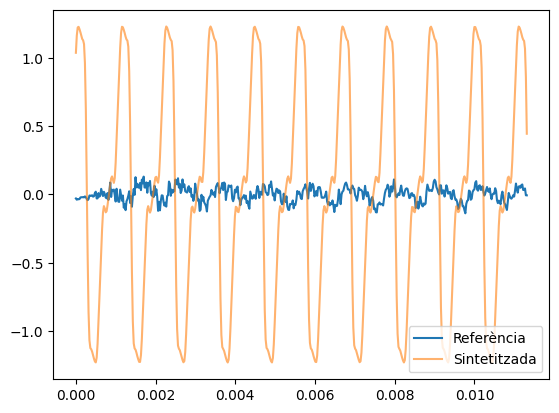

In [26]:
plt.figure()
plt.plot(t[:500], ref[:500], label="Referència")
plt.plot(t[:500], y_synt[:500], label="Sintetitzada", alpha=0.6)
plt.legend()

---

**2. Averaging filter**

Now let's analyze the frequency response of the average filter used in the envelope function. The Scipy Python module has a function called *freqz()* for computing the frequency
response of a discrete-time LTI system. The following Python statements show how to
use freqz to compute and plot both the magnitude (absolute value) and the phase of
the frequency response of a four-point averaging system as a function of ω in the range − π ≤ ω ≤ π :

In [27]:
# Paràmetre del filtre
N = 4  

# Coeficients del filtre
b = np.ones(N) / N

# Resposta freqüencial
w, H = signal.freqz(b, 1, worN=2048, whole=True)
w = w - np.pi   # w en l'interval [-pi, pi]

# Funció dels utils 
plot_frequency_response(w, H)

For FIR filters, the second argument of `freqz(-, 1,- )` must always be equal to 1. The frequency vector ww should cover an interval of length 2π for ω , and its spacing must be fine enough to give a smooth curve for H(ejω) . Note: we will always use capital H for the frequency response.

2.1 Use the `freqz` and `plot_frequency_response` functions to plot the frequency response of the averaging filter of your envelope function.



In [35]:
# Coeficients del filtre
N = 500
b = np.ones(N) / N

# Resposta freqüencial
    # worN controla el número de punts, és elevat perquè el gràfic sigui suau
w, H = signal.freqz(b, 1, worN=2048, whole=True) 
w = w - np.pi

plot_frequency_response(w, H)

2.2 Looking at the frequency responses, what are the main differences between your filter and the four-point averaging filter. What happens when the value N is increased?

**Amb N gran el lòbul principal és més estret i selectiu, per això deixa passar menys freqüències altes. Hi ha més freqüències a zero i la magnitud té una forma de U marcada als extrems pi i -pi.**

**Amb N=4, en canvi, el filtre és molt menys selectiu, el lòbul principal és molt més ample, no hi ha tants zeros i el passabaix és molt suau.**

**Quan augmentem N, el filtre es torna més selectiu i només deixa passar freqüències cada vegada més baixes. La fase varia molt ràpidament i apareixen molts més zeros.**

---

**3. Nulling Filters for Rejection**

Nulling filters are filters that completely eliminate some frequency components. If the frequency is $\omega=0$ or $\omega=\pi$ then a two-point FIR filter will do the nulling. The simplest possible general nulling filter can have as few as three coefficients. If $\omega_n$ is the desired nulling frequency, then the following length-3 FIR filter

$$
y[n] = x[n] - 2\cos(\omega_n)x[n-1] + x[n-2] 
$$

will have a zero in its frequency response at $\omega=\omega_n$. For example, a filter designed to completely eliminate signals of the form $e^{j0.5\pi}$ would have the following coefficients because we would pick the desired nulling frequency to be $\omega_n = 0.5\pi$

$$
b_0 = 1, \quad b1=-2cos(\omega_n)=0, \quad b_2=1
$$

3.1 Use the following function to add an interference in your reference signal. Name the corrupted signal as `x_interf`.

In [36]:
def add_interference(x, fs):
    x_norm = x / np.max(np.abs(x)) * 0.8  # Deixa marge
    f_i = 1000               # freqüència interferència
    A = 0.05   # amplitud de la interferència
    t = np.arange(len(x)) / fs   # vector de temps

    interferencia = A * np.cos(2*np.pi*f_i*t)

    x_interf = x_norm + interferencia
    return x_interf

# Afegim una interferència al senyal de referència mitjançant la funció add_interference, que acabem de generar
x_interf = add_interference(ref, fs)

3.2 Plot both the reference signal and the corrupted signal and listen to the latter one. 

Senyal de referència:


Senyal corrupte:


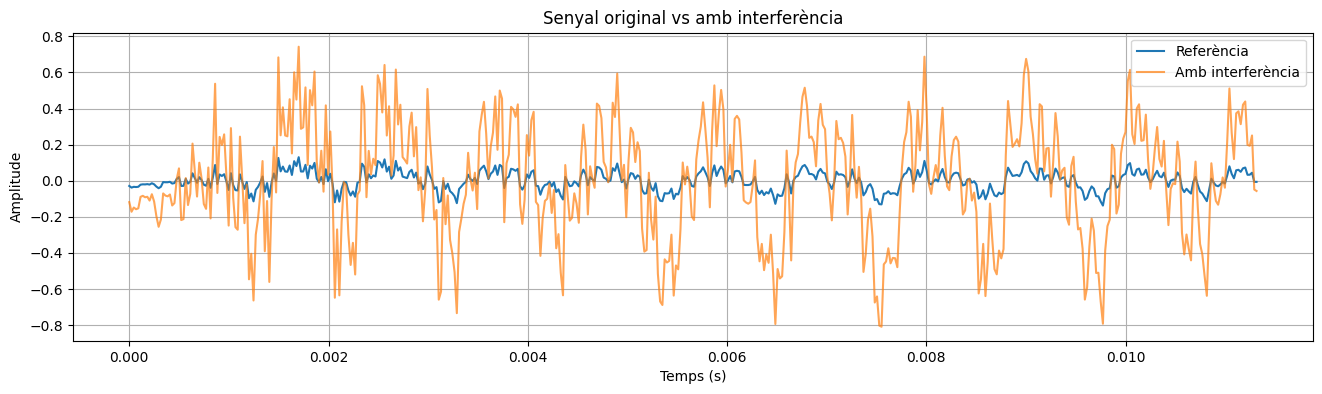

In [30]:
plt.figure(figsize=(16, 4))   # més ample i més baixet
plt.plot(t[:500], ref[:500], label="Referència")
plt.plot(t[:500], x_interf[:500], label="Amb interferència", alpha=0.7)
plt.legend()
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.title("Senyal original vs amb interferència")
plt.grid(True)

# Àudio dels senyals
print("Senyal de referència:")
display(ipd.Audio(ref, rate=fs))

print("Senyal corrupte:")
display(ipd.Audio(x_interf, rate=fs))

3.3 Compare the spectrograms of the reference signal and the interference signal. 

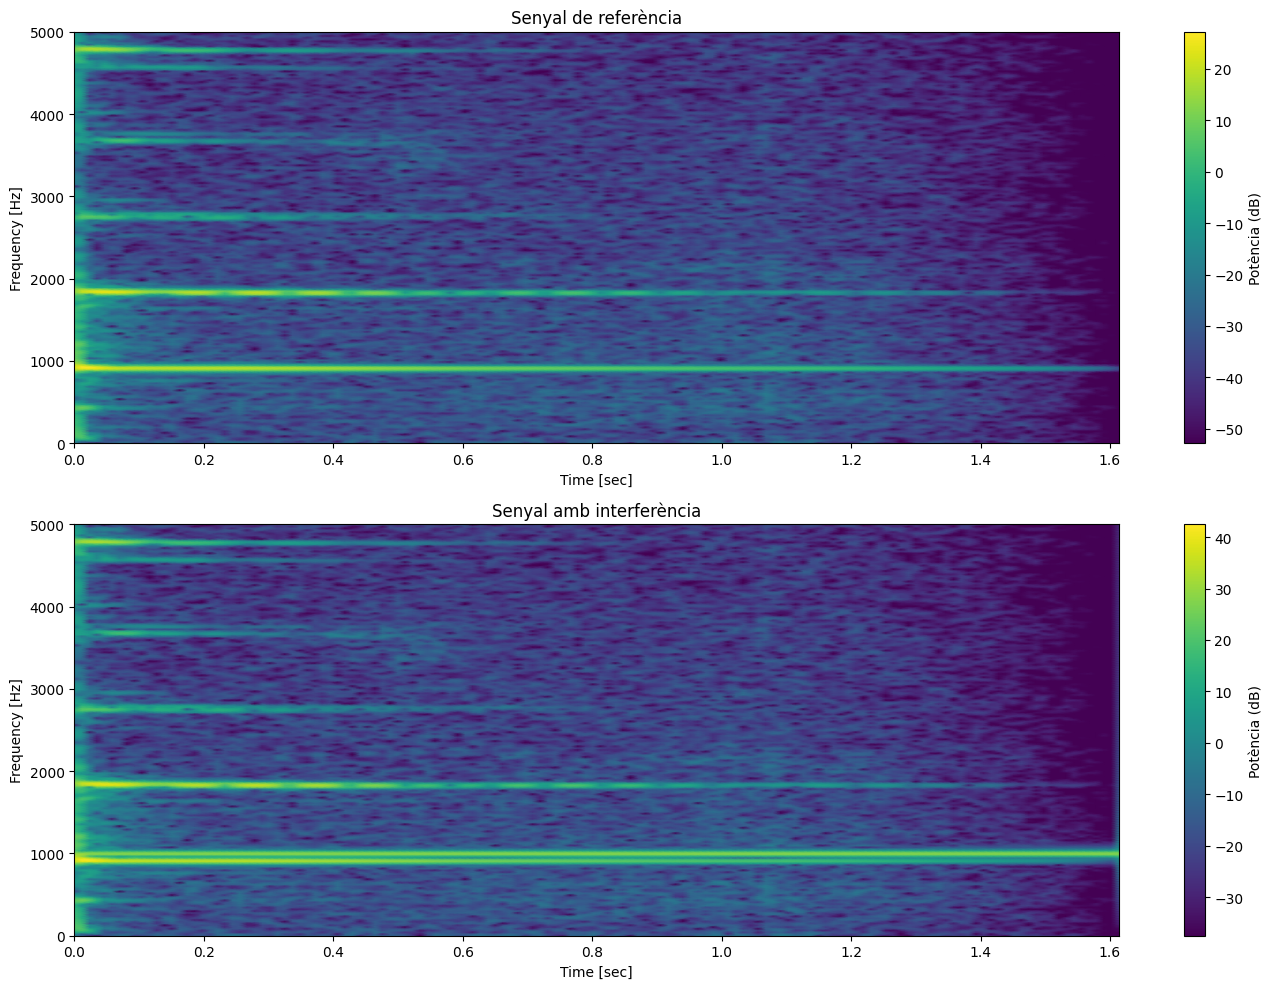

In [31]:
# Paràmetres inicials
n_fft = 2048
hop_length = 512

# Càlcul dels espectrogrames
S_ref = np.abs(librosa.stft(ref, n_fft=n_fft, hop_length=hop_length))**2
S_interf = np.abs(librosa.stft(x_interf, n_fft=n_fft, hop_length=hop_length))**2

# Vectors de temps i freqüència
ff = librosa.fft_frequencies(sr=fs, n_fft=n_fft)
tt = librosa.frames_to_time(np.arange(S_ref.shape[1]), sr=fs, hop_length=hop_length)

# Plot dels espectrogrames
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

    # Espectrograma del senyal de referència
plt.subplot(2, 1, 1)
plot_spectrogram(ff, tt, S_ref)
plt.title("Senyal de referència")
plt.ylim([0, 5000]) 
plt.colorbar(label='Potència (dB)')

    # Espectrograma del senyal amb interferència
plt.subplot(2, 1, 2)
plot_spectrogram(ff, tt, S_interf)
plt.title("Senyal amb interferència")
plt.ylim([0, 5000])
plt.colorbar(label='Potència (dB)')

plt.tight_layout()
plt.show()

3.4. Create a function `remove_interference(x, fs)` that applies a nulling filter devised to remove the interference at 1000 Hz. 

Note: remember that a frequency can be converted to the normalized radian frequncy by: $\omega_n = 2\pi f_n/f_s$

In [32]:
def remove_interference(x, fs):
  """Applies nulling filter to remove an interference at 1000 Hz

  Parameters
  ----------
  x : np.array
      The input signal in the form of a numpy array
  fs : int or float
      Frequency rate in Hz

  Returns
  -------
  y : np.array
      The output of the filter

  """
  # Fórmula del filtre nulling: b[n] = [1, -2*cos(w0), 1]
  f_interf = 1000
  w0 = (2 * np.pi * f_interf) / fs
  b = np.array([1, -2*np.cos(w0), 1])
  y = np.convolve(x, b, mode='same')

  return y

3.5 Use the `remove_interference` funcion to clean the corrupted signal,  `x_interf`. Call the output as `x_clean`. Compare the spectrograms of both signals. Explain the result.

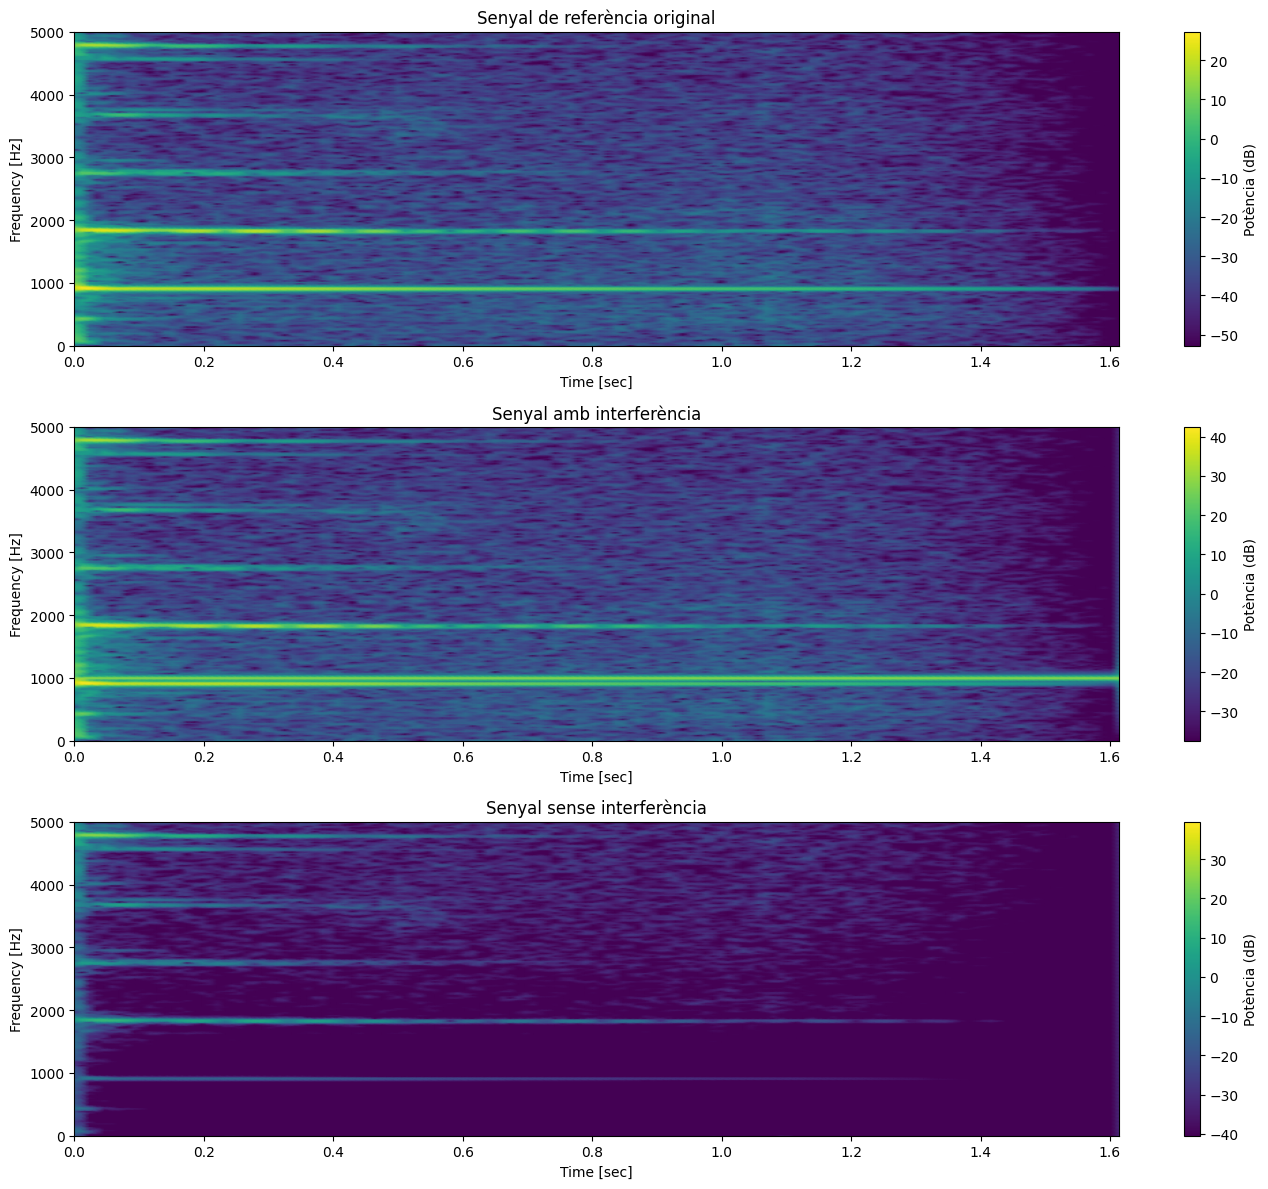


Senyal de referència original:



Senyal amb interferència:



Senyal sense interferència (després del filtre):


In [38]:
x_remove = remove_interference(x_interf, fs)

# Càlcul de l'espectograma del senyal sense interferència
spect_remove = np.abs(librosa.stft(x_remove, n_fft=n_fft, hop_length=hop_length))**2
fig = plt.figure(figsize=(14, 12))

# Espectrograma del senyal de referència original
plt.subplot(3, 1, 1)
plot_spectrogram(ff, tt, S_ref)
plt.title("Senyal de referència original")
plt.ylim([0, 5000])
plt.colorbar(label='Potència (dB)')

# Espectrograma del senyal amb interferència
plt.subplot(3, 1, 2)
plot_spectrogram(ff, tt, S_interf)
plt.title("Senyal amb interferència")
plt.ylim([0, 5000])
plt.colorbar(label='Potència (dB)')

# Espectrograma del senyal sense interferència (després d'aplicar el filtre)
plt.subplot(3, 1, 3)
plot_spectrogram(ff, tt, spect_remove)
plt.title("Senyal sense interferència")
plt.ylim([0, 5000])
plt.colorbar(label='Potència (dB)')

plt.tight_layout()
plt.show()

# Àudio dels senyals
print("\nSenyal de referència original:")
display(ipd.Audio(ref, rate=fs))

print("\nSenyal amb interferència:")
display(ipd.Audio(x_interf, rate=fs))

print("\nSenyal sense interferència (després del filtre):")
display(ipd.Audio(x_remove, rate=fs))
